# PricePilot AI - EDA 2
## Pricing, Competitor, Inventory & Market Analysis

**Milestone 1 contribution:** combine the main business datasets and inspect relationships relevant to dynamic pricing and demand analysis.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path('../data/PricePilot_8_Small_Datasets.xlsx')
sales = pd.read_excel(DATA, sheet_name='02_Historical_Sales')
products = pd.read_excel(DATA, sheet_name='01_Product_Catalog')
competitors = pd.read_excel(DATA, sheet_name='05_Competitor_Prices')
inventory = pd.read_excel(DATA, sheet_name='04_Inventory')
promotions = pd.read_excel(DATA, sheet_name='06_Promotions')
seasonal = pd.read_excel(DATA, sheet_name='07_Seasonal_Events')
market = pd.read_excel(DATA, sheet_name='08_Market_Economic')
for df in [sales, competitors, inventory, market]:
    df['date'] = pd.to_datetime(df['date'])
seasonal['event_date'] = pd.to_datetime(seasonal['event_date'])

## 1. Integrate sales with competitor and market data

In [2]:
competitor_avg = competitors.groupby(['date','product_id'], as_index=False)['competitor_price'].mean()
integrated = sales.merge(products[['product_id','category','cost_price','list_price']], on='product_id', how='left')
integrated = integrated.merge(competitor_avg, on=['date','product_id'], how='left')
integrated = integrated.merge(market, on='date', how='left')
integrated['competitor_gap_pct'] = (integrated['selling_price'] - integrated['competitor_price']) / integrated['competitor_price'] * 100
integrated['gross_profit_per_unit'] = integrated['selling_price'] - integrated['cost_price']
print('Integrated shape:', integrated.shape)
print(integrated.head())

Integrated shape: (1800, 16)
        date product_id  selling_price  discount_pct  units_sold    revenue  \
0 2026-05-01       P001       21420.75             5           7  149945.26   
1 2026-05-02       P001       19165.94            15           9  172493.42   
2 2026-05-03       P001       22548.16             0           9  202933.44   
3 2026-05-04       P001       22548.16             0           8  180385.28   
4 2026-05-05       P001       22548.16             0           7  157837.12   

        category  cost_price  list_price  competitor_price  \
0  Running Shoes    15607.06    22548.16               NaN   
1  Running Shoes    15607.06    22548.16               NaN   
2  Running Shoes    15607.06    22548.16               NaN   
3  Running Shoes    15607.06    22548.16               NaN   
4  Running Shoes    15607.06    22548.16               NaN   

   market_demand_index  demand_growth_rate  inflation_rate  \
0                1.171              -0.013           0.068   

## 2. Pricing and demand relationships

In [3]:
cols = ['selling_price','units_sold','discount_pct','competitor_price','market_demand_index','demand_growth_rate','inflation_rate','market_search_index','revenue']
print(integrated[cols].corr()['units_sold'].sort_values().round(3))

competitor_price      -0.126
selling_price         -0.113
market_demand_index   -0.035
market_search_index   -0.008
inflation_rate        -0.004
demand_growth_rate     0.001
discount_pct           0.062
revenue                0.482
units_sold             1.000
Name: units_sold, dtype: float64


   discount_pct  avg_units_sold  avg_selling_price  records
0             0           15.10           25465.88      846
1             5           15.32           24152.36      447
2            10           15.82           22286.49      331
3            15           16.59           21131.88      176


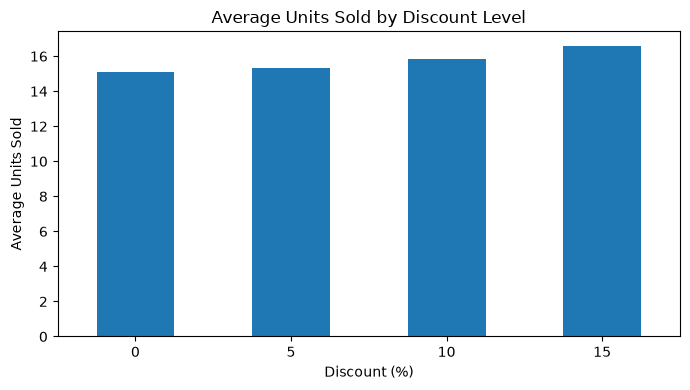

In [4]:
discount_effect = sales.groupby('discount_pct').agg(avg_units_sold=('units_sold','mean'), avg_selling_price=('selling_price','mean'), records=('units_sold','size')).reset_index()
print(discount_effect.round(2))
discount_effect.plot(x='discount_pct', y='avg_units_sold', kind='bar', figsize=(7,4), legend=False)
plt.title('Average Units Sold by Discount Level')
plt.xlabel('Discount (%)')
plt.ylabel('Average Units Sold')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 3. Competitor pricing

In [5]:
print('Average competitor price:', round(integrated['competitor_price'].mean(),2))
print('Average selling price:', round(integrated['selling_price'].mean(),2))
print('Average price gap (%):', round(integrated['competitor_gap_pct'].mean(),2))
print('Selling price vs competitor price correlation:', round(integrated['selling_price'].corr(integrated['competitor_price']),3))

Average competitor price: 24636.0
Average selling price: 24131.26
Average price gap (%): -1.58
Selling price vs competitor price correlation: 0.991


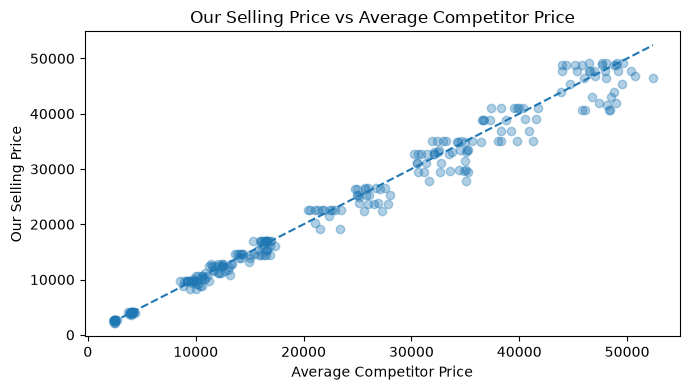

In [6]:
sample = integrated.sample(min(800, len(integrated)), random_state=42)
plt.figure(figsize=(7,4))
plt.scatter(sample['competitor_price'], sample['selling_price'], alpha=0.35)
lims=[min(sample['competitor_price'].min(),sample['selling_price'].min()),max(sample['competitor_price'].max(),sample['selling_price'].max())]
plt.plot(lims,lims, linestyle='--')
plt.title('Our Selling Price vs Average Competitor Price')
plt.xlabel('Average Competitor Price')
plt.ylabel('Our Selling Price')
plt.tight_layout()
plt.show()

## 4. Inventory and promotion checks

In [7]:
print('Inventory records:', inventory.shape)
print('Stockout records:', int(inventory['stockout_flag'].sum()))
print('Average closing stock:', round(inventory['closing_stock'].mean(),2))
print('Active promotions:', int(promotions['promotion_active'].sum()), 'of', len(promotions))
print('\nPromotion summary:')
print(promotions.groupby('promotion_type').agg(products=('product_id','count'), avg_discount=('discount_pct','mean')).sort_values('products', ascending=False).round(2))

Inventory records: (600, 7)
Stockout records: 0
Average closing stock: 159.91
Active promotions: 14 of 20

Promotion summary:
                products  avg_discount
promotion_type                        
No Promotion           6           0.0
Festival Sale          5          15.0
Weekend Offer          4          10.0
Flash Sale             3          20.0
Clearance              2          20.0


## 5. Seasonal and market context

In [8]:
print('Seasonal events:')
print(seasonal.to_string(index=False))
print('\nMarket statistics:')
print(market[['market_demand_index','demand_growth_rate','inflation_rate','market_search_index']].describe().round(3))

Seasonal events:
event_date        event_name  expected_demand_multiplier
2026-05-01       Summer Sale                        1.15
2026-05-10  Weekend Campaign                        1.05
2026-05-25       Summer Sale                        1.15
2026-06-05 Festival Campaign                        1.10
2026-06-15     Mid-Year Sale                        1.25
2026-06-25     Mid-Year Sale                        1.20
2026-07-05      Monsoon Sale                        1.10
2026-07-15      Monsoon Sale                        1.15

Market statistics:
       market_demand_index  demand_growth_rate  inflation_rate  \
count               90.000              90.000          90.000   
mean                 1.064               0.033           0.051   
std                  0.090               0.038           0.012   
min                  0.905              -0.028           0.031   
25%                  0.983              -0.002           0.041   
50%                  1.069               0.033        

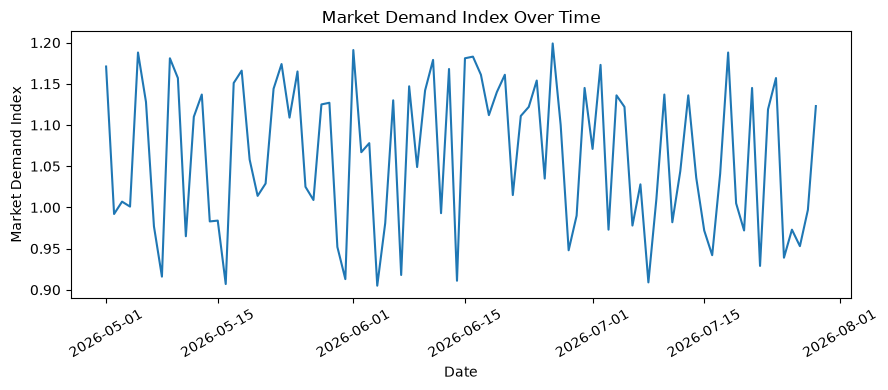

In [9]:
daily_market = market.groupby('date').agg(market_demand_index=('market_demand_index','mean'), market_search_index=('market_search_index','mean')).reset_index()
plt.figure(figsize=(9,4))
plt.plot(daily_market['date'], daily_market['market_demand_index'])
plt.title('Market Demand Index Over Time')
plt.xlabel('Date')
plt.ylabel('Market Demand Index')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

## 6. Initial findings

- The integrated dataset connects historical sales with product attributes, competitor pricing, and market indicators.
- Our selling price has a very strong positive relationship with competitor price in the supplied data, showing that prices generally move with the market.
- The simple price-to-demand relationship is weak, indicating that demand should not be modeled from price alone.
- Higher discount levels show higher average units sold in the supplied records, but this is descriptive and does not prove causation.
- No stockout records are present in the inventory sheet, so stockout effects cannot be evaluated from this dataset.
- Promotions, seasonal events, competitor prices, and market indicators are useful candidate features for later price prediction and demand forecasting.

In [10]:
print('EDA 2 completed successfully.')

EDA 2 completed successfully.


In [11]:
import pandas as pd
from pathlib import Path

DATA = Path("../data/PricePilot_8_Small_Datasets.xlsx")

products = pd.read_excel(DATA, sheet_name="01_Product_Catalog")
sales = pd.read_excel(DATA, sheet_name="02_Historical_Sales")

sales["date"] = pd.to_datetime(sales["date"])

In [12]:
# KPI Summary

total_revenue = sales["revenue"].sum()
total_units = sales["units_sold"].sum()
avg_selling_price = sales["selling_price"].mean()

sales["profit"] = (sales["selling_price"] - products.set_index("product_id")["cost_price"].reindex(sales["product_id"]).values) * sales["units_sold"]
total_profit = sales["profit"].sum()

print("Total Revenue:", round(total_revenue, 2))
print("Total Units Sold:", total_units)
print("Average Selling Price:", round(avg_selling_price, 2))
print("Total Profit:", round(total_profit, 2))

Total Revenue: 649717121.99
Total Units Sold: 27777
Average Selling Price: 24131.26
Total Profit: 146584353.6


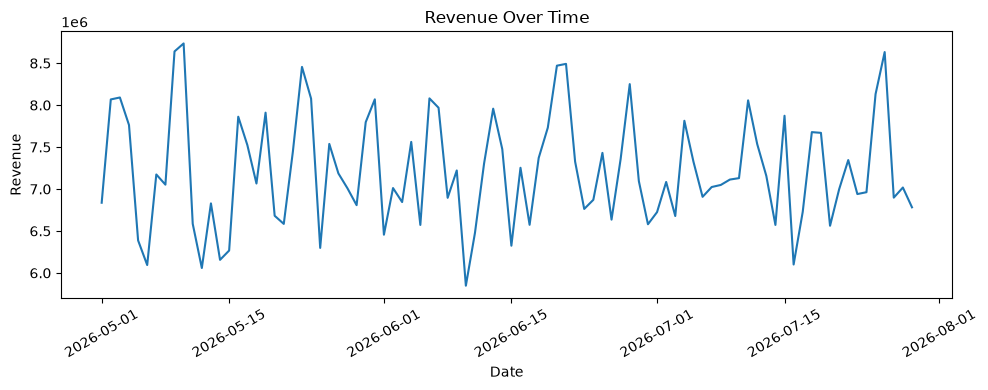

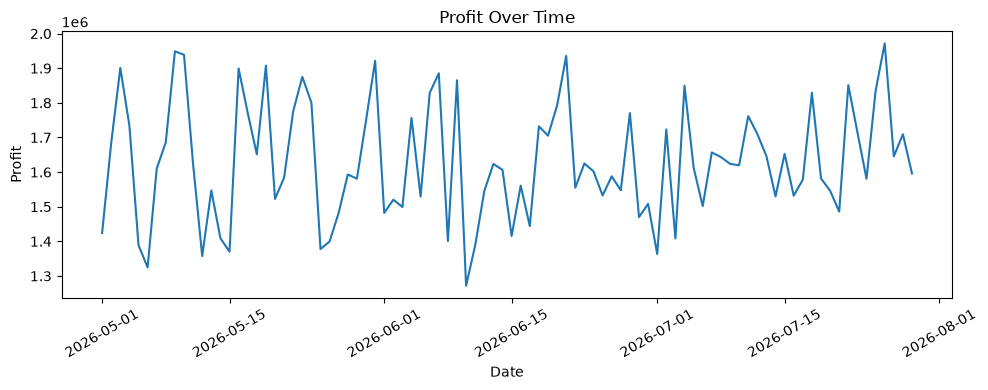

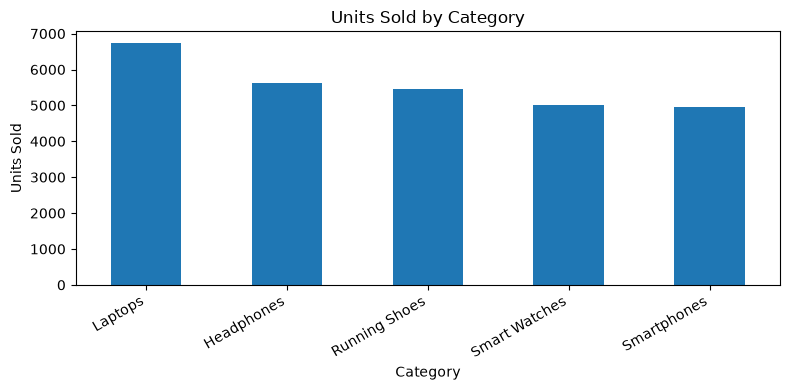

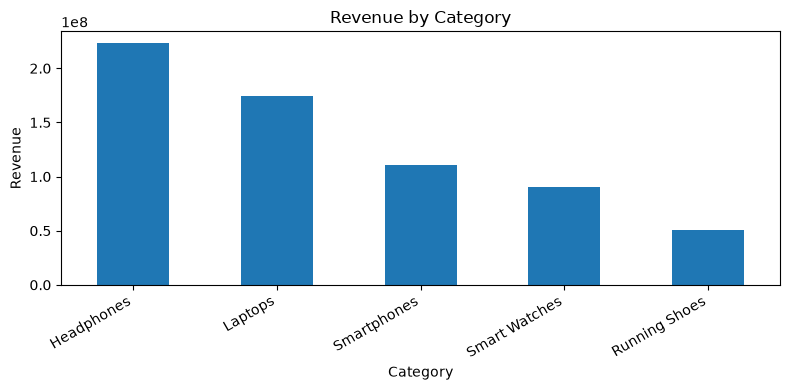

In [13]:
import matplotlib.pyplot as plt

# Daily revenue
daily_revenue = sales.groupby("date")["revenue"].sum()

plt.figure(figsize=(10, 4))
plt.plot(daily_revenue.index, daily_revenue.values)
plt.title("Revenue Over Time")
plt.xlabel("Date")
plt.ylabel("Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Daily profit
daily_profit = sales.groupby("date")["profit"].sum()

plt.figure(figsize=(10, 4))
plt.plot(daily_profit.index, daily_profit.values)
plt.title("Profit Over Time")
plt.xlabel("Date")
plt.ylabel("Profit")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


# Units sold by category
sales_cat = sales.merge(
    products[["product_id", "category"]],
    on="product_id",
    how="left"
)

category_units = sales_cat.groupby("category")["units_sold"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
category_units.plot(kind="bar")
plt.title("Units Sold by Category")
plt.xlabel("Category")
plt.ylabel("Units Sold")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


# Revenue by category
category_revenue = sales_cat.groupby("category")["revenue"].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
category_revenue.plot(kind="bar")
plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## Key Findings from Visual Analysis

### Revenue Over Time

Revenue fluctuates considerably over the observed period, indicating variations in sales performance across different dates.

### Profit Over Time

Profit also shows noticeable fluctuations over time. These changes are influenced by variations in selling prices, product costs, and sales volume.

### Units Sold by Category

The category-wise analysis shows differences in product demand. Laptops have the highest number of units sold among the displayed categories.

### Revenue by Category

Revenue contribution varies significantly across product categories. Headphones generate the highest revenue, followed by laptops and smartphones.

### Demand Forecast

The 30-day demand forecast shows different expected demand levels across products. Products with higher forecasted demand may require greater inventory availability, while products with lower forecasted demand can be managed with comparatively lower stock levels.

### Business Implications

The combined analysis of historical sales, revenue, profit, and forecasted demand can support pricing decisions, inventory planning, and identification of high-performing product categories.